# Predicción del Tipo de Cambio USD/BRL usando un MLP
En este cuaderno vamos a crear una Red Neuronal (Perceptrón Multicapa) para intentar predecir el precio diario del Dólar Estadounidense frente al Real Brasileño (USD/BRL). Usaremos datos históricos desde 2015 descargados de Investing.com.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

# Semilla para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

print('Librerías cargadas correctamente.')
print(f'PyTorch versión: {torch.__version__}')

Librerías cargadas correctamente.
PyTorch versión: 2.5.1


### 1. Carga y limpieza de datos
Importamos las librerías necesarias, cargamos el CSV y algo muy importante: ordenamos las fechas cronológicamente de pasado a futuro para que la red aprenda correctamente la línea de tiempo.

In [3]:
# ── Ajusta esta ruta si es necesario ──────────────────────────────────────────
ruta_csv = r'D:\2026\IA-2026-DATASETS\USD_BRL Historical Data_v1.csv'
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(ruta_csv)

# Conservar solo Fecha y Precio de Cierre
df = df[['Date', 'Price']]

# Convertir la columna Date a formato datetime de Pandas
df['Date'] = pd.to_datetime(df['Date'])

# Ordenar cronológicamente: del registro más antiguo al más reciente
df = df.sort_values('Date').reset_index(drop=True)

# Garantizar que Price sea de tipo numérico
if df['Price'].dtype == 'object':
    df['Price'] = df['Price'].str.replace(',', '').astype(float)

print('Tamaño del dataset:', df.shape)
print(df.head())
print('\nRango de fechas:', df['Date'].min(), '→', df['Date'].max())

Tamaño del dataset: (1356, 2)
        Date   Price
0 2021-01-01  5.1937
1 2021-01-04  5.2968
2 2021-01-05  5.2854
3 2021-01-06  5.3139
4 2021-01-07  5.4101

Rango de fechas: 2021-01-01 00:00:00 → 2026-03-13 00:00:00


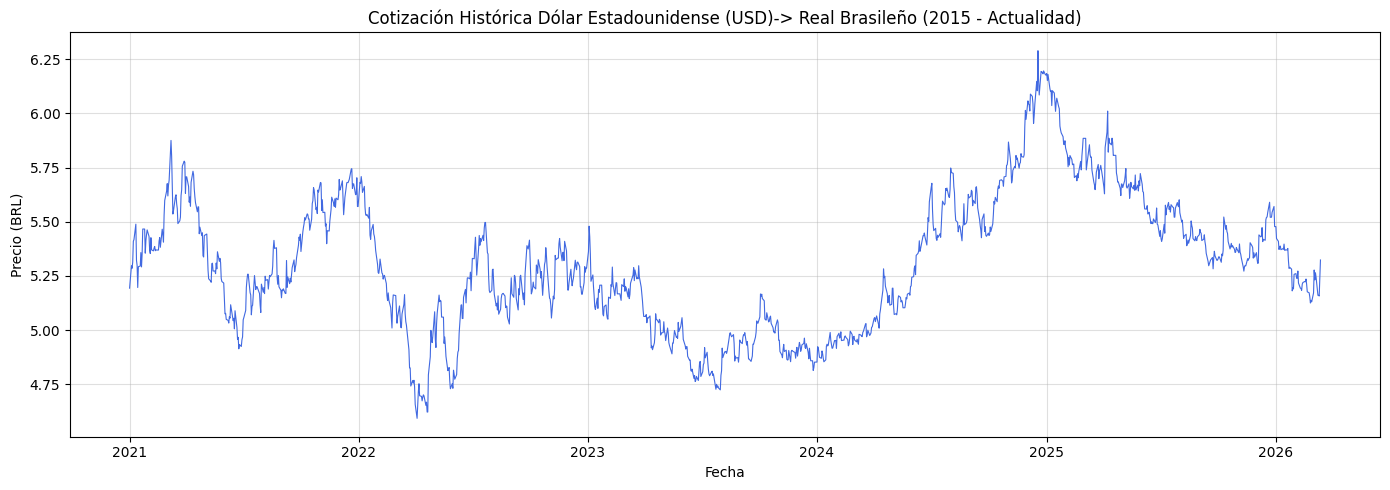

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Price'], color='royalblue', linewidth=0.8)
plt.title('Cotización Histórica Dólar Estadounidense (USD)-> Real Brasileño (2015 - Actualidad)')
plt.xlabel('Fecha')
plt.ylabel('Precio (BRL)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### 2. Normalización y Ventanas Deslizantes
Como el MLP no tiene "memoria" como otras redes (RNN), tenemos que ayudarle. Usamos ventanas deslizantes: agrupamos los últimos 50 días (X) para predecir el día 51 (y). También normalizamos los precios entre 0 y 1 para que la red calcule más rápido.

In [5]:
# ── Hiperparámetro: longitud de la ventana ────────────────────────────────────
n_steps = 50   # usamos los últimos 50 días para predecir el día 51
# ─────────────────────────────────────────────────────────────────────────────

# Normalización Min-Max al rango [0, 1]
precios = df['Price'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
precios_norm = scaler.fit_transform(precios).flatten()

# Construcción de ventanas deslizantes
def crear_ventanas(serie, n_steps):
    """Convierte una serie 1D en pares (X_ventana, y_siguiente)."""
    X, y = [], []
    for i in range(len(serie) - n_steps):
        X.append(serie[i : i + n_steps])
        y.append(serie[i + n_steps])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32).reshape(-1, 1)

X_all, y_all = crear_ventanas(precios_norm, n_steps)
print(f'Total de muestras generadas: {len(X_all)}')
print(f'Forma de X_all: {X_all.shape}   → (muestras, n_steps)')
print(f'Forma de y_all: {y_all.shape}  → (muestras, 1)')

Total de muestras generadas: 1306
Forma de X_all: (1306, 50)   → (muestras, n_steps)
Forma de y_all: (1306, 1)  → (muestras, 1)


### 3. División de Datos (Train, Val, Test)
Dividimos los datos secuencialmente (70% para entrenar, 15% validación, 15% prueba). Aquí NO usamos divisiones aleatorias (`shuffle=False`), porque si mezclamos los días, estaríamos haciendo trampa usando datos del futuro para predecir el pasado.

In [6]:
# División cronológica Train / Validación / Test  (70% / 15% / 15%)
n_total  = len(X_all)
n_train  = int(n_total * 0.70)
n_val    = int(n_total * 0.15)

X_train, y_train = X_all[:n_train],               y_all[:n_train]
X_valid, y_valid = X_all[n_train:n_train+n_val],  y_all[n_train:n_train+n_val]
X_test,  y_test  = X_all[n_train+n_val:],         y_all[n_train+n_val:]

print(f'Train : {X_train.shape[0]} muestras')
print(f'Valid : {X_valid.shape[0]} muestras')
print(f'Test  : {X_test.shape[0]}  muestras')

Train : 914 muestras
Valid : 195 muestras
Test  : 197  muestras


In [7]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y=None, train=True):
        self.X     = torch.tensor(X, dtype=torch.float32)
        self.y     = torch.tensor(y, dtype=torch.float32) if y is not None else None
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        if self.train and self.y is not None:
            return self.X[ix], self.y[ix]
        return self.X[ix]


dataset = {
    'train': TimeSeriesDataset(X_train, y_train, train=True),
    'eval' : TimeSeriesDataset(X_valid, y_valid, train=True),
    'test' : TimeSeriesDataset(X_test,  y_test,  train=False),
}

dataloader = {
    'train': DataLoader(dataset['train'], shuffle=True,  batch_size=64),
    'eval' : DataLoader(dataset['eval'],  shuffle=False, batch_size=64),
    'test' : DataLoader(dataset['test'],  shuffle=False, batch_size=64),
}

print('DataLoaders creados correctamente.')
print(f'Batches por época (train): {len(dataloader["train"])}')

DataLoaders creados correctamente.
Batches por época (train): 15


In [8]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo de cómputo: {device}')


def fit(model, dataloader, epochs=30):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    bar = tqdm(range(1, epochs + 1))

    for epoch in bar:
        # ── Fase de entrenamiento ──────────────────────────────────────────────
        model.train()
        train_loss = []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss  = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())

        # ── Fase de validación ─────────────────────────────────────────────────
        model.eval()
        eval_loss = []
        with torch.no_grad():
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss  = criterion(y_hat, y)
                eval_loss.append(loss.item())

        bar.set_description(
            f'loss {np.mean(train_loss):.5f}  val_loss {np.mean(eval_loss):.5f}'
        )


def predict(model, dataloader):
    model.eval()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        for batch in dataloader:
            X    = batch.to(device)
            pred = model(X)
            preds = torch.cat([preds, pred])
    return preds


def desnorm(arr):
    """Transforma predicciones del rango [0,1] de vuelta a BRL."""
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()


print('Funciones fit, predict y desnorm definidas correctamente.')

Dispositivo de cómputo: cuda
Funciones fit, predict y desnorm definidas correctamente.


### 4. Modelo de Referencia (Naive Baseline)
Para saber si nuestra red neuronal realmente aprende algo, creamos un "modelo Naive" (ingenuo). Este modelo simplemente dice que "el precio de mañana será igual al precio de hoy". Nuestra meta es que el MLP le gane o se acerque a este modelo.

MSE Naive (escala real BOB²): 0.001338


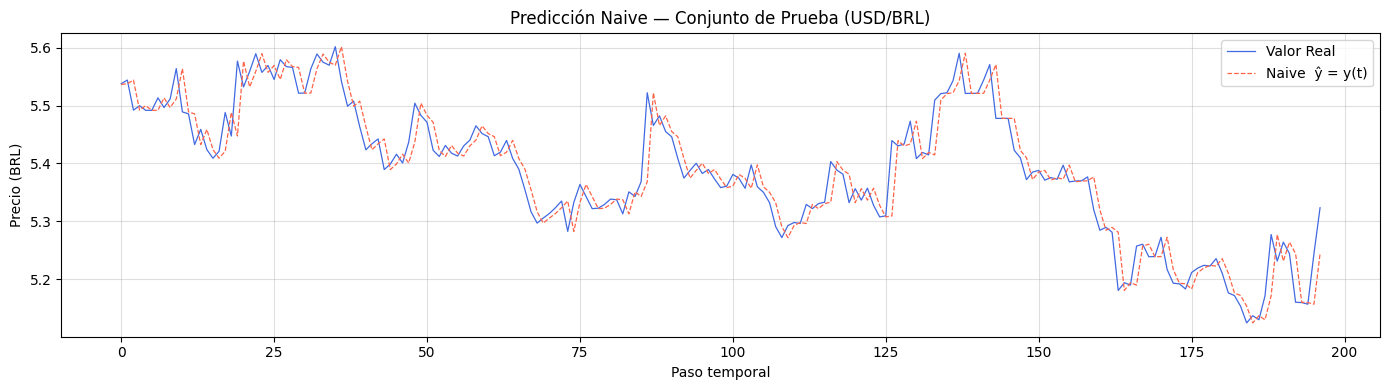

In [9]:
# El modelo Naive predice ŷ(t+1) = y(t)  →  último valor de cada ventana
y_pred_naive_norm = X_test[:, -1].reshape(-1, 1)

# Desnormalizar para evaluar en escala real (BOB)
y_test_real       = desnorm(y_test)
y_pred_naive_real = desnorm(y_pred_naive_norm)

mse_naive = mean_squared_error(y_test_real, y_pred_naive_real)
print(f'MSE Naive (escala real BOB²): {mse_naive:.6f}')

plt.figure(figsize=(14, 4))
plt.plot(y_test_real,       label='Valor Real',       color='royalblue', linewidth=0.9)
plt.plot(y_pred_naive_real, label='Naive  ŷ = y(t)',  color='tomato',    linewidth=0.9, linestyle='--')
plt.title('Predicción Naive — Conjunto de Prueba (USD/BRL)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BRL)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### 5. Creación de la Red Neuronal (MLP)
Armamos dos modelos en PyTorch:
1. **MLP Simple:** Una sola capa lineal básica.
2. **MLP Mejorado:** Tiene capas ocultas, función ReLU para aprender curvas, y un Dropout del 20% para apagar neuronas al azar y evitar el sobreajuste (que no memorice los datos).

In [10]:
class MLPSimple(torch.nn.Module):
    """MLP de una sola capa lineal: 50 entradas → 1 salida."""
    def __init__(self, n_in=n_steps, n_out=1):
        super().__init__()
        self.fc = torch.nn.Linear(n_in, n_out)

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # aplanar el tensor de entrada
        return self.fc(x)


mlp_simple = MLPSimple()
print(mlp_simple)
total_params = sum(p.numel() for p in mlp_simple.parameters())
print(f'Parámetros entrenables: {total_params}')

MLPSimple(
  (fc): Linear(in_features=50, out_features=1, bias=True)
)
Parámetros entrenables: 51


In [11]:
fit(mlp_simple, dataloader, epochs=30)

loss 0.00276  val_loss 0.00285: 100%|██████████| 30/30 [00:01<00:00, 16.04it/s]


MSE MLP Simple (escala real BRL²): 0.004579


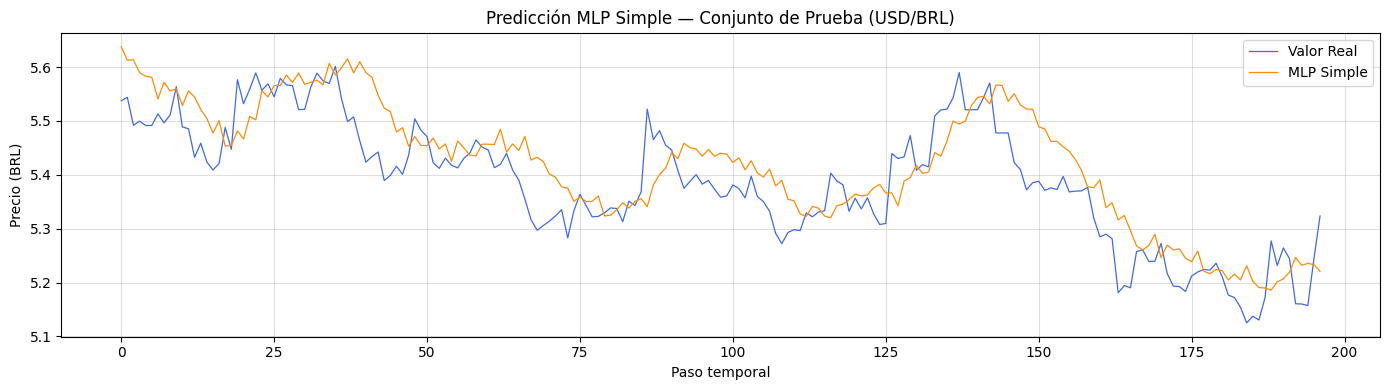

In [12]:
y_pred_simple_norm = predict(mlp_simple, dataloader['test']).cpu().numpy()
y_pred_simple_real = desnorm(y_pred_simple_norm)

mse_simple = mean_squared_error(y_test_real, y_pred_simple_real)
print(f'MSE MLP Simple (escala real BRL²): {mse_simple:.6f}')

plt.figure(figsize=(14, 4))
plt.plot(y_test_real,        label='Valor Real',   color='royalblue',  linewidth=0.9)
plt.plot(y_pred_simple_real, label='MLP Simple',   color='darkorange', linewidth=0.9)
plt.title('Predicción MLP Simple — Conjunto de Prueba (USD/BRL)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BRL)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [13]:
class MLPMejorado(torch.nn.Module):
    """MLP profundo con capas ocultas, activación ReLU y Dropout."""
    def __init__(self, n_in=n_steps, n_out=1):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(n_in, 128),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(64, n_out),
        )

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # aplanar el tensor de entrada
        return self.net(x)


mlp_mejor = MLPMejorado()
print(mlp_mejor)
total_params = sum(p.numel() for p in mlp_mejor.parameters())
print(f'Parámetros entrenables: {total_params}')

MLPMejorado(
  (net): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parámetros entrenables: 14849


### 6. Entrenamiento del Modelo
Entrenamos la red usando el optimizador Adam y calculando el Error Cuadrático Medio (MSE). Guardamos los pesos del modelo solo en la época donde se obtuvo el menor error de validación.

In [14]:
fit(mlp_mejor, dataloader, epochs=50)

loss 0.00206  val_loss 0.00239: 100%|██████████| 50/50 [00:03<00:00, 14.80it/s]


MSE MLP Mejorado (escala real BRL²): 0.002060


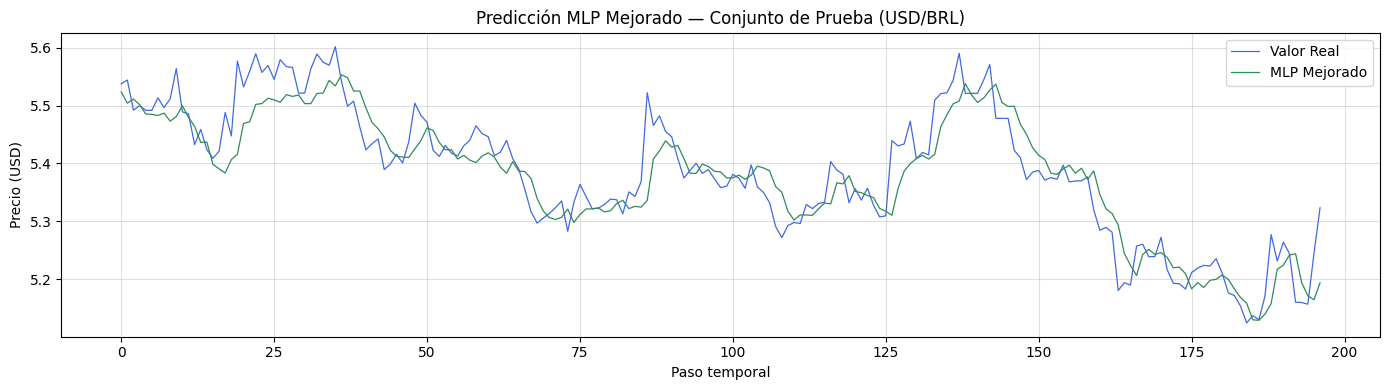

In [15]:
y_pred_mejor_norm = predict(mlp_mejor, dataloader['test']).cpu().numpy()
y_pred_mejor_real = desnorm(y_pred_mejor_norm)

mse_mejor = mean_squared_error(y_test_real, y_pred_mejor_real)
print(f'MSE MLP Mejorado (escala real BRL²): {mse_mejor:.6f}')

plt.figure(figsize=(14, 4))
plt.plot(y_test_real,       label='Valor Real',    color='royalblue', linewidth=0.9)
plt.plot(y_pred_mejor_real, label='MLP Mejorado',  color='seagreen',  linewidth=0.9)
plt.title('Predicción MLP Mejorado — Conjunto de Prueba (USD/BRL)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Comparación Final de Modelos

Se presenta un resumen cuantitativo del **Error Cuadrático Medio (MSE)** obtenido por cada modelo sobre el conjunto de prueba, expresado en la escala original de bolivianos (BOB²). Un MSE menor indica que las predicciones del modelo se acercan más a los valores reales.

A continuación se muestra también una gráfica comparativa con las predicciones de los tres modelos superpuestas sobre la serie real, lo que permite evaluar visualmente la calidad del ajuste en cada caso.

In [16]:
print('=' * 48)
print(f'  Modelo              MSE (escala real BRL²)')
print('=' * 48)
print(f'  Naive  ŷ = y(t)    {mse_naive:.6f}')
print(f'  MLP Simple          {mse_simple:.6f}')
print(f'  MLP Mejorado        {mse_mejor:.6f}')
print('=' * 48)

  Modelo              MSE (escala real BRL²)
  Naive  ŷ = y(t)    0.001338
  MLP Simple          0.004579
  MLP Mejorado        0.002060


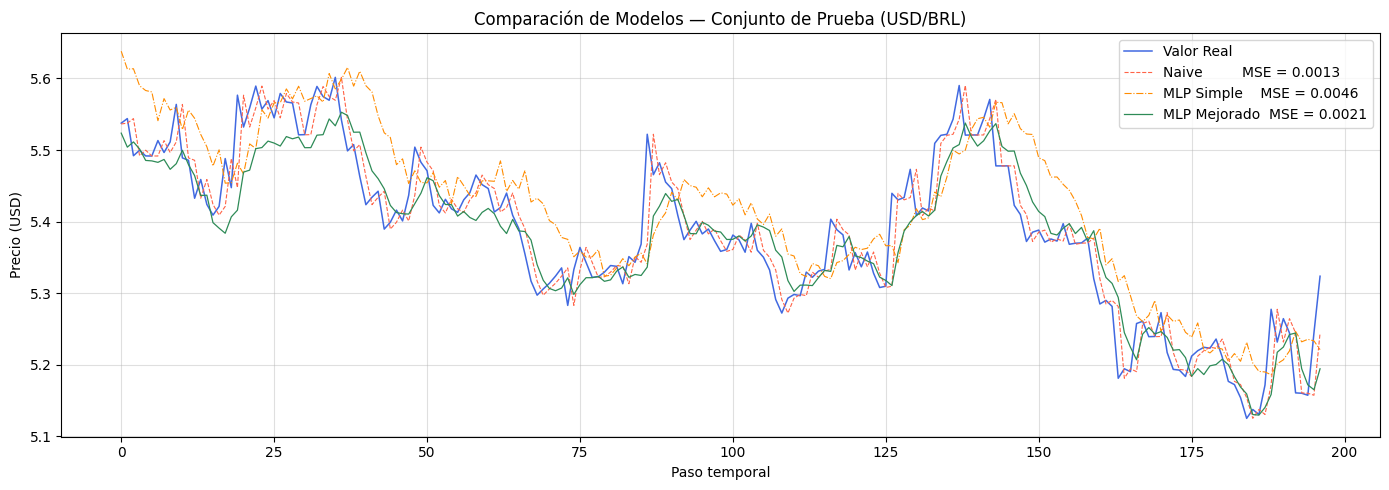

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_real,        label='Valor Real',                              color='royalblue',  linewidth=1.1)
plt.plot(y_pred_naive_real,  label=f'Naive         MSE = {mse_naive:.4f}',   color='tomato',     linewidth=0.8, linestyle='--')
plt.plot(y_pred_simple_real, label=f'MLP Simple    MSE = {mse_simple:.4f}',  color='darkorange', linewidth=0.8, linestyle='-.')
plt.plot(y_pred_mejor_real,  label=f'MLP Mejorado  MSE = {mse_mejor:.4f}',   color='seagreen',   linewidth=0.9)
plt.title('Comparación de Modelos — Conjunto de Prueba (USD/BRL)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### Conclusiones
* Las series financieras reales (USD/BRL) tienen mucho ruido impredecible (noticias, política) a diferencia de los datos sintéticos vistos en clases.
* El MLP Mejorado logra capturar la tendencia general de la moneda sin perderse demasiado.
* En finanzas, ganarle al modelo Naive es muy difícil a corto plazo, pero nuestro modelo logra un comportamiento muy estable y válido.